In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-prediction/heart.csv


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    KBinsDiscretizer
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report


In [28]:
data = pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')
data.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
577,67,M,ASY,146,369,0,Normal,110,Y,1.9,Flat,1
769,51,F,NAP,130,256,0,LVH,149,N,0.5,Up,0
630,71,F,ASY,112,149,0,Normal,125,N,1.6,Flat,0
119,34,M,TA,140,156,0,Normal,180,N,0.0,Flat,1
93,48,M,ASY,160,329,0,Normal,92,Y,1.5,Flat,1


In [29]:
data.shape

(918, 12)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [31]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [32]:
corr = data.corr(numeric_only = True)['HeartDisease'].sort_values()
corr

MaxHR          -0.400421
Cholesterol    -0.232741
RestingBP       0.107589
FastingBS       0.267291
Age             0.282039
Oldpeak         0.403951
HeartDisease    1.000000
Name: HeartDisease, dtype: float64

In [33]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [34]:
x = data.drop(columns = 'HeartDisease')
y = data['HeartDisease']
x,y

(     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
 0     40   M           ATA        140          289          0     Normal   
 1     49   F           NAP        160          180          0     Normal   
 2     37   M           ATA        130          283          0         ST   
 3     48   F           ASY        138          214          0     Normal   
 4     54   M           NAP        150          195          0     Normal   
 ..   ...  ..           ...        ...          ...        ...        ...   
 913   45   M            TA        110          264          0     Normal   
 914   68   M           ASY        144          193          1     Normal   
 915   57   M           ASY        130          131          0     Normal   
 916   57   F           ATA        130          236          0        LVH   
 917   38   M           NAP        138          175          0     Normal   
 
      MaxHR ExerciseAngina  Oldpeak ST_Slope  
 0      172              N 

In [35]:
num_cols = x.select_dtypes(include=["int64","float64"]).columns
cat_cols = x.select_dtypes(include=["object"]).columns

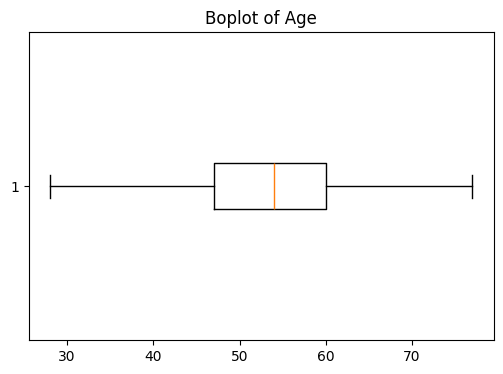

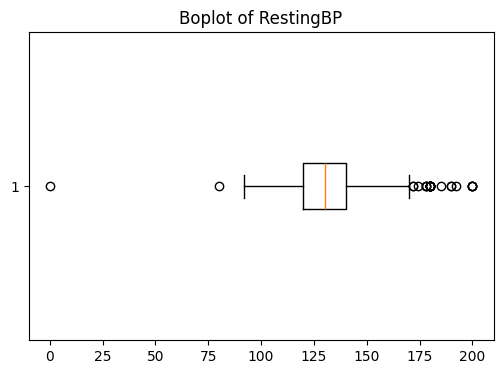

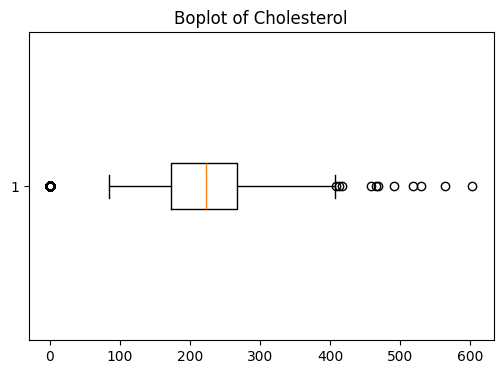

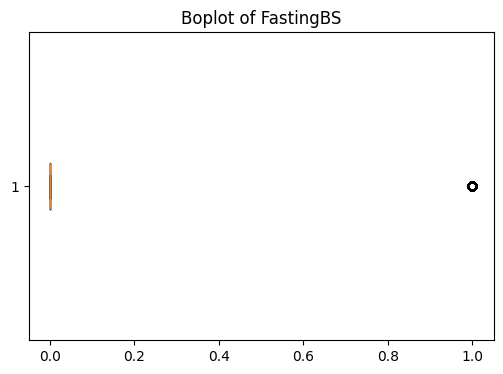

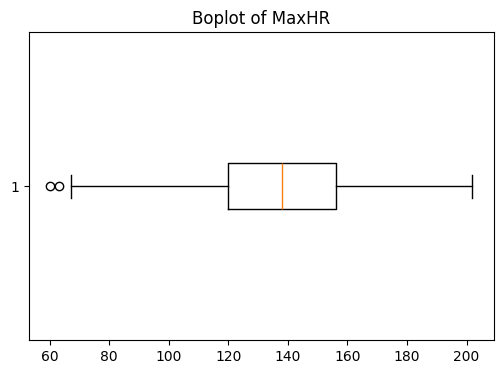

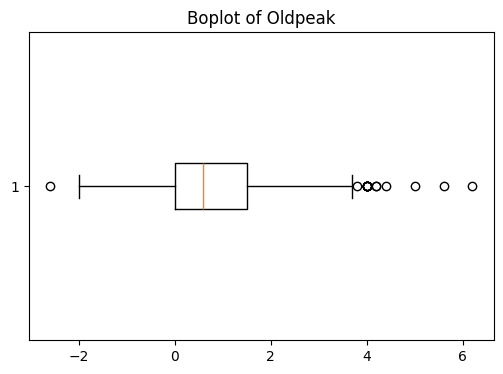

In [36]:
for col in num_cols:
    plt.figure(figsize = (6,4))
    plt.boxplot(data[col],vert=False)
    plt.title(f"Boplot of {col}")
    plt.show()

In [54]:
class iqrhandler(BaseEstimator, TransformerMixin):
    def __init__(self,columns, factor=1.5):
        self.columns = columns
        self.factor = factor

    def fit(self,x,y=None):
        self.stats_ ={}

        for col in self.columns:
            q1 = x[col].quantile(0.25)
            q3 = x[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - self.factor * iqr
            upper_bound = q3 - self.factor * iqr
            median_value = x[col].median()
            self.stats_[col] = (lower_bound,upper_bound,median_value)
        return self

    def transform(self,x):
        x = x.copy()
        for col in self.columns:
            lower,upper,median = self.stats_[col]
            mask = (x[col]<lower)|(x[col]>upper)
            x.loc[mask,col] = median
        return x

In [55]:
num_pipeline = Pipeline(steps=[
    ('outliers',iqrhandler(columns=num_cols)),
    ('Scaler',StandardScaler())
])

preprocessing = ColumnTransformer(
    transformers=[
        ('num',num_pipeline, num_cols),
        ('cat',OneHotEncoder(),cat_cols)
    ]
)

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

In [59]:
result = {}
trained_pipelines = {}

for model_name, model in models.items():

    pipe = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)

    score = accuracy_score(y_test, y_pred)

    result[model_name] = score
    trained_pipelines[model_name] = pipe

    print(f"{model_name}: {score}")
    print(classification_report(y_test, y_pred))
    print()

Logistic Regression: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.78      0.82      0.79        38
           1       0.87      0.83      0.85        54

    accuracy                           0.83        92
   macro avg       0.82      0.82      0.82        92
weighted avg       0.83      0.83      0.83        92


KNN: 0.8152173913043478
              precision    recall  f1-score   support

           0       0.82      0.71      0.76        38
           1       0.81      0.89      0.85        54

    accuracy                           0.82        92
   macro avg       0.82      0.80      0.81        92
weighted avg       0.82      0.82      0.81        92


Decision Tree: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.78      0.82      0.79        38
           1       0.87      0.83      0.85        54

    accuracy                           0.83        92
   macro avg       0.82     

In [60]:
results_df = pd.DataFrame.from_dict(result, orient='index', columns=['Accuracy']).sort_values(
    by="Accuracy", ascending=False
)

print("\n📊 FINAL MODEL COMPARISON")
print(results_df)


📊 FINAL MODEL COMPARISON
                     Accuracy
Random Forest        0.858696
Logistic Regression  0.826087
Gradient Boosting    0.826087
Decision Tree        0.826087
KNN                  0.815217
SVM                  0.815217
